# Cargar datos

In [1]:
import pandas as pd

archivo="data_set_limpio_sin_not_for_sale"
file_path = f'datasets_pkl/{archivo}.pkl'

df = pd.read_pickle(file_path)

# Display the loaded DataFrame
print(df.columns) 


Index(['Nat', 'Division', 'Club', 'Based', 'Preferred Foot', 'Right Foot',
       'Left Foot', 'Position', 'Height', 'Weight', 'Age', 'Wage', 'AT Apps',
       'AT Gls', 'Team', 'Caps', 'Yth Apps', 'Style', 'Rc Injury', 'Best Role',
       'Best Duty', 'Best Pos', 'Acc', 'Aer', 'Agg', 'Agi', 'Ant', 'Bal',
       'Bra', 'Cmd', 'Com', 'Cmp', 'Cnt', 'Cor', 'Cro', 'Dec', 'Det', 'Dri',
       'Ecc', 'Fin', 'Fir', 'Fla', 'Fre', 'Han', 'Hea', 'Jum', 'Kic', 'Ldr',
       'Lon', 'L Th', 'Mar', 'Nat .1', 'OtB', '1v1', 'Pac', 'Pas', 'Pen',
       'Pos', 'Pun', 'Ref', 'TRO', 'Sta', 'Str', 'Tck', 'Tea', 'Tec', 'Thr',
       'Vis', 'Wor', 'transfer_value_estimado'],
      dtype='object')


In [2]:
import pandas as pd
visualizar_todo=False
if visualizar_todo:
    # Show all rows
    pd.set_option('display.max_rows', None)

    # Show all columns
    pd.set_option('display.max_columns', None)

    # Show full content of each cell (prevent text truncation)
    pd.set_option('display.max_colwidth', None)


# Generar dataset de ligas, naciones y clubes

In [3]:
# Seleccion de columna, "Division", "Nat", "Club"
CANT_CLUSTERS = 5
columna="Club"

## Generar caracteristicas por liga/nacion/club

In [4]:
import numpy as np
target="transfer_value_estimado"

# Create new dataframe with only numeric columns
num_cols = df.select_dtypes(include=np.number).columns
num_cols = [col for col in num_cols if col != target]
grouped = df.groupby(columna)[num_cols]
df_new = grouped.agg(['mean', 'std'])
df_new.columns = ['{}_{}'.format(col, stat) for col, stat in df_new.columns]
df_new = df_new.reset_index()
df_new.shape

(12291, 111)

In [5]:
from sklearn.preprocessing import StandardScaler

# Keep Nat separately
nat_names = df_new[columna]

X_new = df_new.drop(columns=[columna])

# Fill NaNs (std can be NaN for small groups)
X_new =X_new .fillna(0)

# Scale (VERY important for KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_new)

## Kmeans

### Método del codo para seleccionar la cantidad de clusters

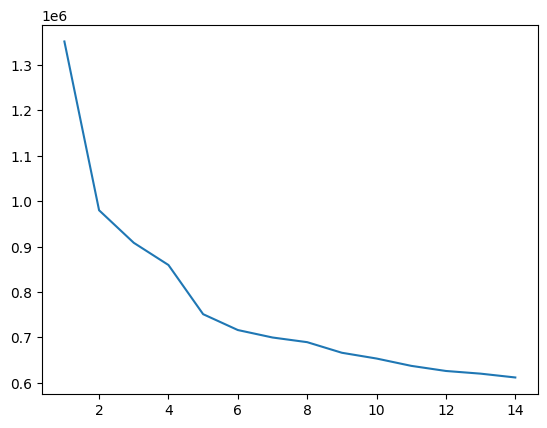

In [6]:
from sklearn.cluster import KMeans
inertia = []
for k in range(1, 15):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

import matplotlib.pyplot as plt
plt.plot(range(1, 15), inertia)
plt.show()

### kmeans

In [7]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=CANT_CLUSTERS, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

### Creación de una columna con el cluster correspondiente al pais 

In [8]:
df_new[f'{columna}_cluster'] = clusters
nat_to_cluster = dict(zip(df_new[columna], df_new[f'{columna}_cluster']))


### Visualización de clusters

In [9]:
df_new[[columna, f'{columna}_cluster']].sort_values(f'{columna}_cluster')

,Club,Club_cluster
3843,FC Rapid,0
10564,São Borja,0
8771,RW Essen,0
10563,São Bernardo,0
2993,Deportivo Cali,0
...,...,...
9545,Safa,4
9544,Sadovo,4
911,Argentinos del Norte (C),4
5987,Korinos,4


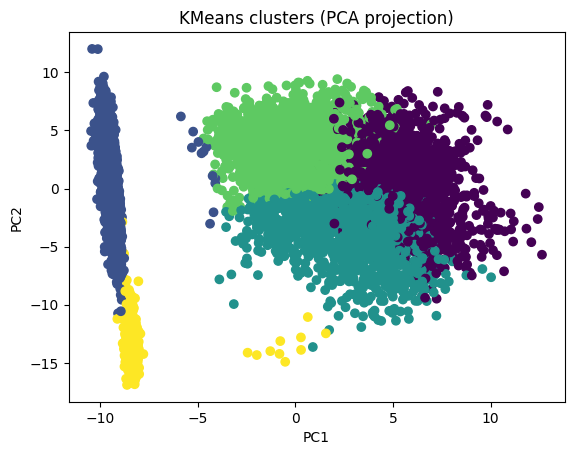

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)

# # Optional: label each point (nationality)
# for i, new in enumerate(df_new[columna]):
#     plt.text(X_pca[i, 0], X_pca[i, 1], new, fontsize=8)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans clusters (PCA projection)')
plt.show()

# Creación de feature y asignación de cluster a cada jugador en el dataset

In [11]:
new_to_cluster = dict(zip(df_new[columna], df_new[f'{columna}_cluster']))

In [16]:
import pandas as pd

archivo="data_set_limpio_sin_not_for_sale_post_kmeans"
file_path_objetivo = f'datasets_pkl/{archivo}.pkl'

df_objetivo = pd.read_pickle(file_path_objetivo)

df_objetivo[f'{columna}_cluster'] = df_objetivo[columna].map(new_to_cluster)

In [17]:
print(df_objetivo.columns) 

Index(['Nat', 'Division', 'Club', 'Based', 'Preferred Foot', 'Right Foot',
       'Left Foot', 'Position', 'Height', 'Weight', 'Age', 'Wage', 'AT Apps',
       'AT Gls', 'Team', 'Caps', 'Yth Apps', 'Style', 'Rc Injury', 'Best Role',
       'Best Duty', 'Best Pos', 'Acc', 'Aer', 'Agg', 'Agi', 'Ant', 'Bal',
       'Bra', 'Cmd', 'Com', 'Cmp', 'Cnt', 'Cor', 'Cro', 'Dec', 'Det', 'Dri',
       'Ecc', 'Fin', 'Fir', 'Fla', 'Fre', 'Han', 'Hea', 'Jum', 'Kic', 'Ldr',
       'Lon', 'L Th', 'Mar', 'Nat .1', 'OtB', '1v1', 'Pac', 'Pas', 'Pen',
       'Pos', 'Pun', 'Ref', 'TRO', 'Sta', 'Str', 'Tck', 'Tea', 'Tec', 'Thr',
       'Vis', 'Wor', 'transfer_value_estimado', 'Division_cluster',
       'Nat_cluster', 'Club_cluster'],
      dtype='object')


# Almcanenamiento del dataframe con las nuevas features 

In [14]:
crear_nuevo=True
if crear_nuevo:
    df_objetivo.to_pickle(file_path_objetivo)